# 01 — Data Understanding & EDA

## Objetivo
Este notebook documenta la carga, limpieza y análisis exploratorio inicial del dataset de churn. El propósito es:

1. validar la calidad del dato,
2. entender la estructura de variables numéricas y categóricas,
3. identificar patrones preliminares asociados al churn,
4. y dejar preparado el dataset para la fase de modelado.

## Preguntas que responde
- ¿Cuál es la estructura del dataset?
- ¿Qué transformaciones de limpieza son necesarias?
- ¿Qué variables parecen más relacionadas con el churn?
- ¿Qué hallazgos de negocio emergen antes del modelado?

In [41]:
from pathlib import Path
import sys

# Buscar la raíz del proyecto (la carpeta que contiene "src")
PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = C:\repos\tfm-proyecto1-churn


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, kurtosis

# Importaciones de nuestros módulos (conectando con la carpeta src)
from src.data.load_data import load_telco_data
from src.data.clean_data import clean_telco_data
from src.features.feature_lists import TARGET, CAT_COLS, NUM_COLS

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
import warnings
warnings.filterwarnings('ignore')

In [43]:
df_raw = load_telco_data()
df_raw.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [44]:
print("Shape crudo:", df_raw.shape)
df_raw.info()

Shape crudo: (7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-nu

**Nota sobre el dataset crudo:** Como podemos observar, el dataset original incluye la columna `customerID` (que no aporta valor predictivo) y la variable `TotalCharges` viene con problemas de tipado (aparece como `object` en lugar de `float`). Aún no se ha aplicado limpieza.

In [45]:
df = clean_telco_data(df_raw)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [46]:
print("Shape limpio:", df.shape)
df.info()

Shape limpio: (7043, 20)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-n

**Nota tras la limpieza:**
- La columna `customerID` ya no está.
- La columna `TotalCharges` ya es numérica y los valores nulos (clientes con `tenure = 0`) han sido imputados lógicamente con 0.
- El dataset queda listo para el EDA y modelado.

In [47]:
print(df[TARGET].value_counts())
print("\nPorcentaje:")
print(df[TARGET].value_counts(normalize=True).round(4) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Porcentaje:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


**Sobre la variable objetivo:**
Estamos ante un problema de clasificación binaria que presenta un **desbalance moderado** (aprox. 73.5% vs 26.5%). Esto nos indica que métricas globales como el `accuracy` por sí solas no serán suficientes para evaluar los modelos futuros; necesitaremos fijarnos en el Recall y Precision.

In [48]:
df[NUM_COLS].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80


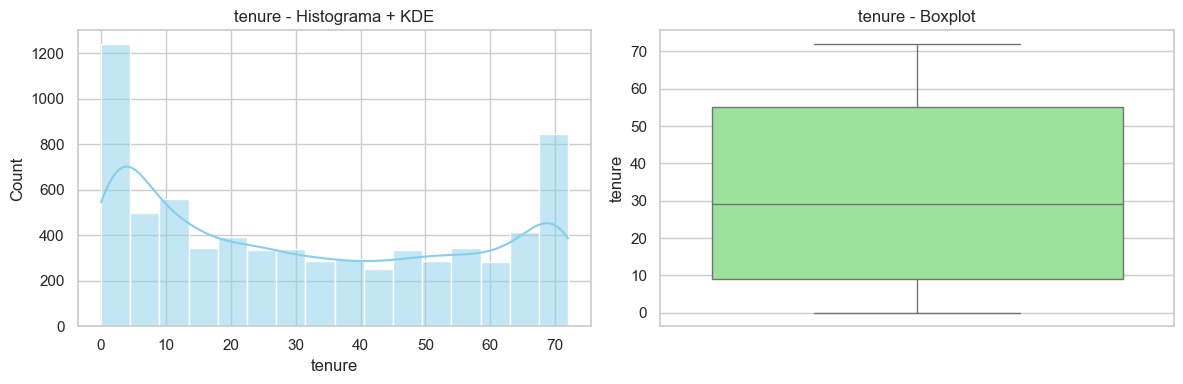


--- tenure ---
count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64
Asimetría (skew): 0.24
Curtosis: -1.39
--------------------------------------------------


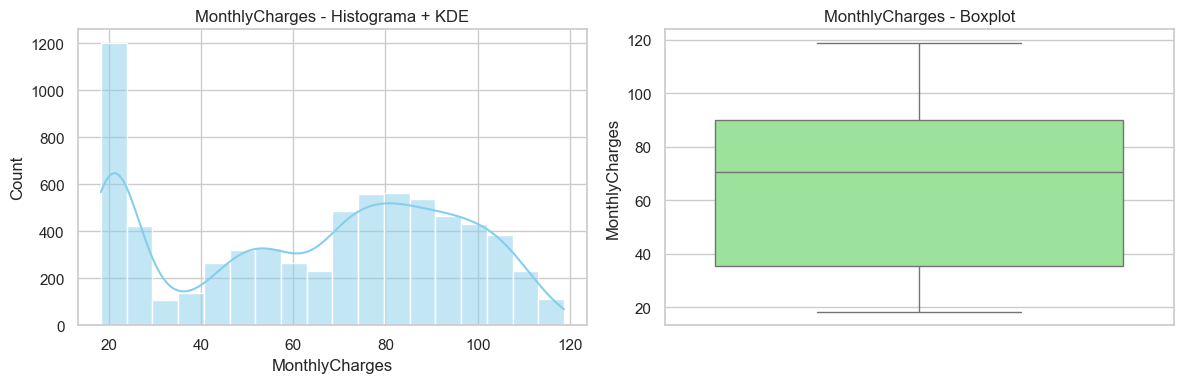


--- MonthlyCharges ---
count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64
Asimetría (skew): -0.22
Curtosis: -1.26
--------------------------------------------------


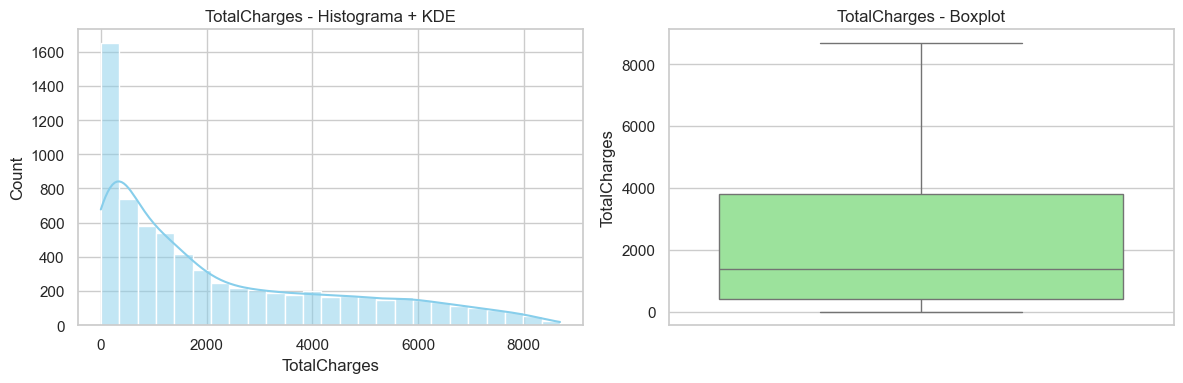


--- TotalCharges ---
count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
25%       398.550000
50%      1394.550000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64
Asimetría (skew): 0.96
Curtosis: -0.23
--------------------------------------------------


In [49]:
def plot_numeric_univariate(data, columns):
    for col in columns:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        sns.histplot(data[col], kde=True, ax=axes[0], color="skyblue")
        axes[0].set_title(f"{col} - Histograma + KDE")
        axes[0].set_xlabel(col)

        sns.boxplot(y=data[col], ax=axes[1], color="lightgreen")
        axes[1].set_title(f"{col} - Boxplot")
        axes[1].set_ylabel(col)

        plt.tight_layout()
        plt.show()

        print(f"\n--- {col} ---")
        print(data[col].describe())
        print(f"Asimetría (skew): {skew(data[col].dropna()):.2f}")
        print(f"Curtosis: {kurtosis(data[col].dropna()):.2f}")
        print("-" * 50)


plot_numeric_univariate(df, NUM_COLS)

### Conclusión Numérica
- `tenure`: Muestra una distribución bimodal, indicando una gran concentración de clientes muy nuevos (0-5 meses) y clientes muy leales (>60 meses).
- `MonthlyCharges`: Sugiere la existencia de segmentos tarifarios diferenciados (hay picos claros alrededor de 20 y 80 dólares).
- `TotalCharges`: Es una variable acumulativa y, lógicamente, muestra una clara asimetría positiva (skewness > 0).


--- gender ---
        count  percentage
gender                   
Male     3555       50.48
Female   3488       49.52

--- SeniorCitizen ---
               count  percentage
SeniorCitizen                   
0               5901       83.79
1               1142       16.21

--- Partner ---
         count  percentage
Partner                   
No        3641        51.7
Yes       3402        48.3

--- Dependents ---
            count  percentage
Dependents                   
No           4933       70.04
Yes          2110       29.96

--- PhoneService ---
              count  percentage
PhoneService                   
Yes            6361       90.32
No              682        9.68

--- MultipleLines ---
                  count  percentage
MultipleLines                      
No                 3390       48.13
Yes                2971       42.18
No phone service    682        9.68

--- InternetService ---
                 count  percentage
InternetService                   
Fiber optic 

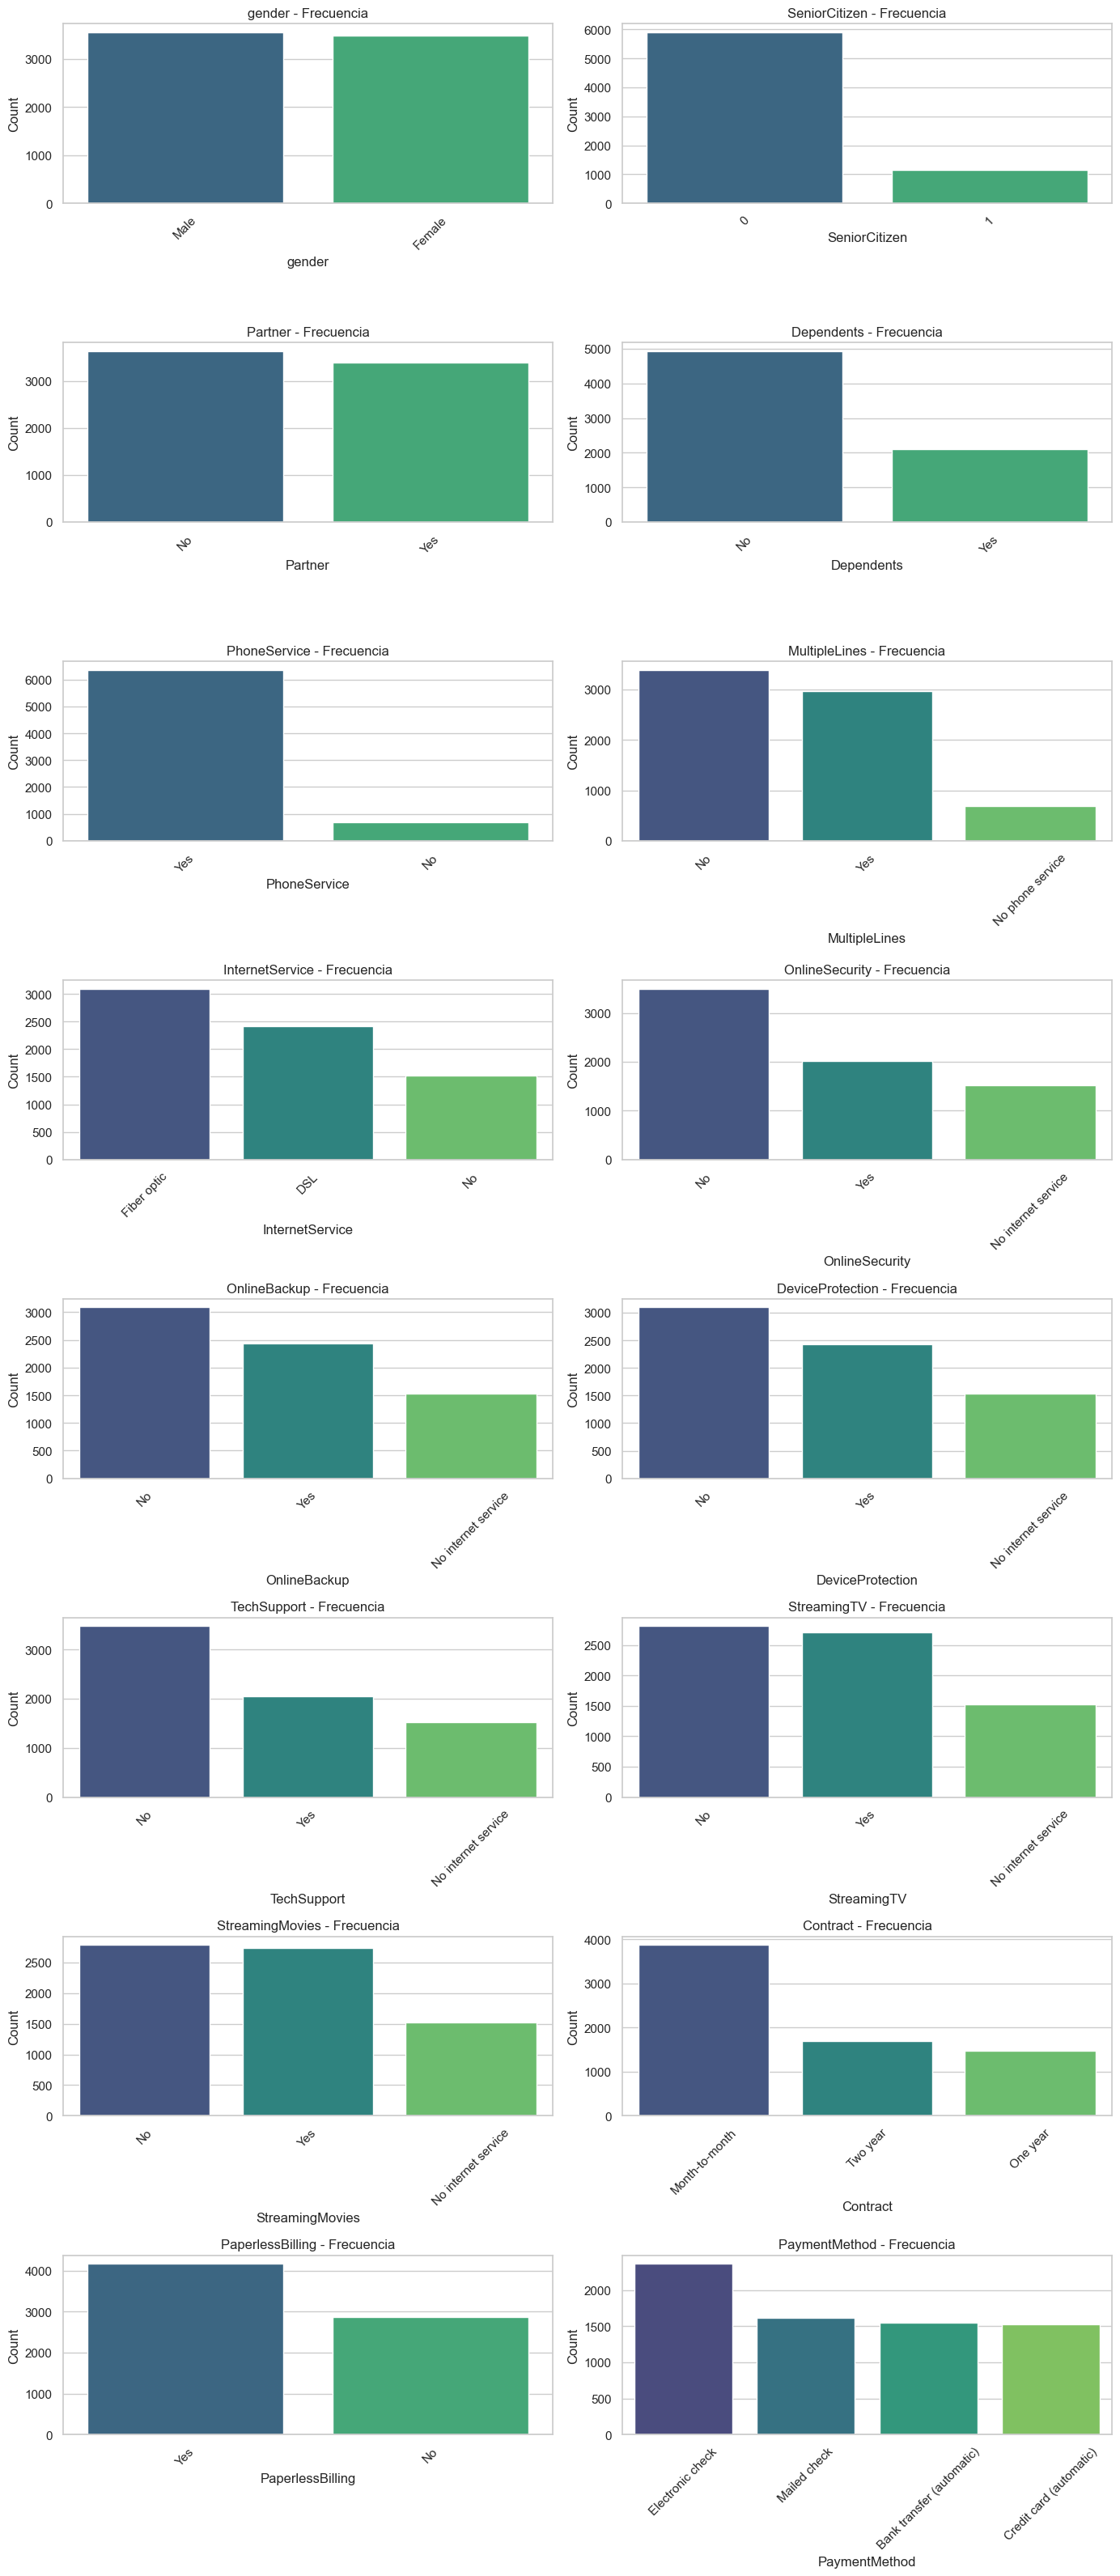

In [50]:
def plot_categorical_univariate(data, columns, ncols=2):
    n = len(columns)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(columns):
        ax = axes[i]

        counts = data[col].value_counts(dropna=False)
        props = data[col].value_counts(normalize=True, dropna=False) * 100

        sns.barplot(x=counts.index.astype(str), y=counts.values, ax=ax, palette="viridis")
        ax.set_title(f"{col} - Frecuencia")
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
        ax.tick_params(axis="x", rotation=45)

        print(f"\n--- {col} ---")
        summary = pd.DataFrame({
            "count": counts,
            "percentage": props.round(2)
        })
        print(summary)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

plot_categorical_univariate(df, CAT_COLS, ncols=2)

### Conclusión Categórica
- Variables como `Contract`, `InternetService` y `PaymentMethod` muestran distribuciones muy interesantes que podrían ser clave.
- Existen categorías estructurales cruzadas (por ejemplo, si no tienen Internet, aparecen como `No internet service` en múltiples variables de seguridad y soporte).

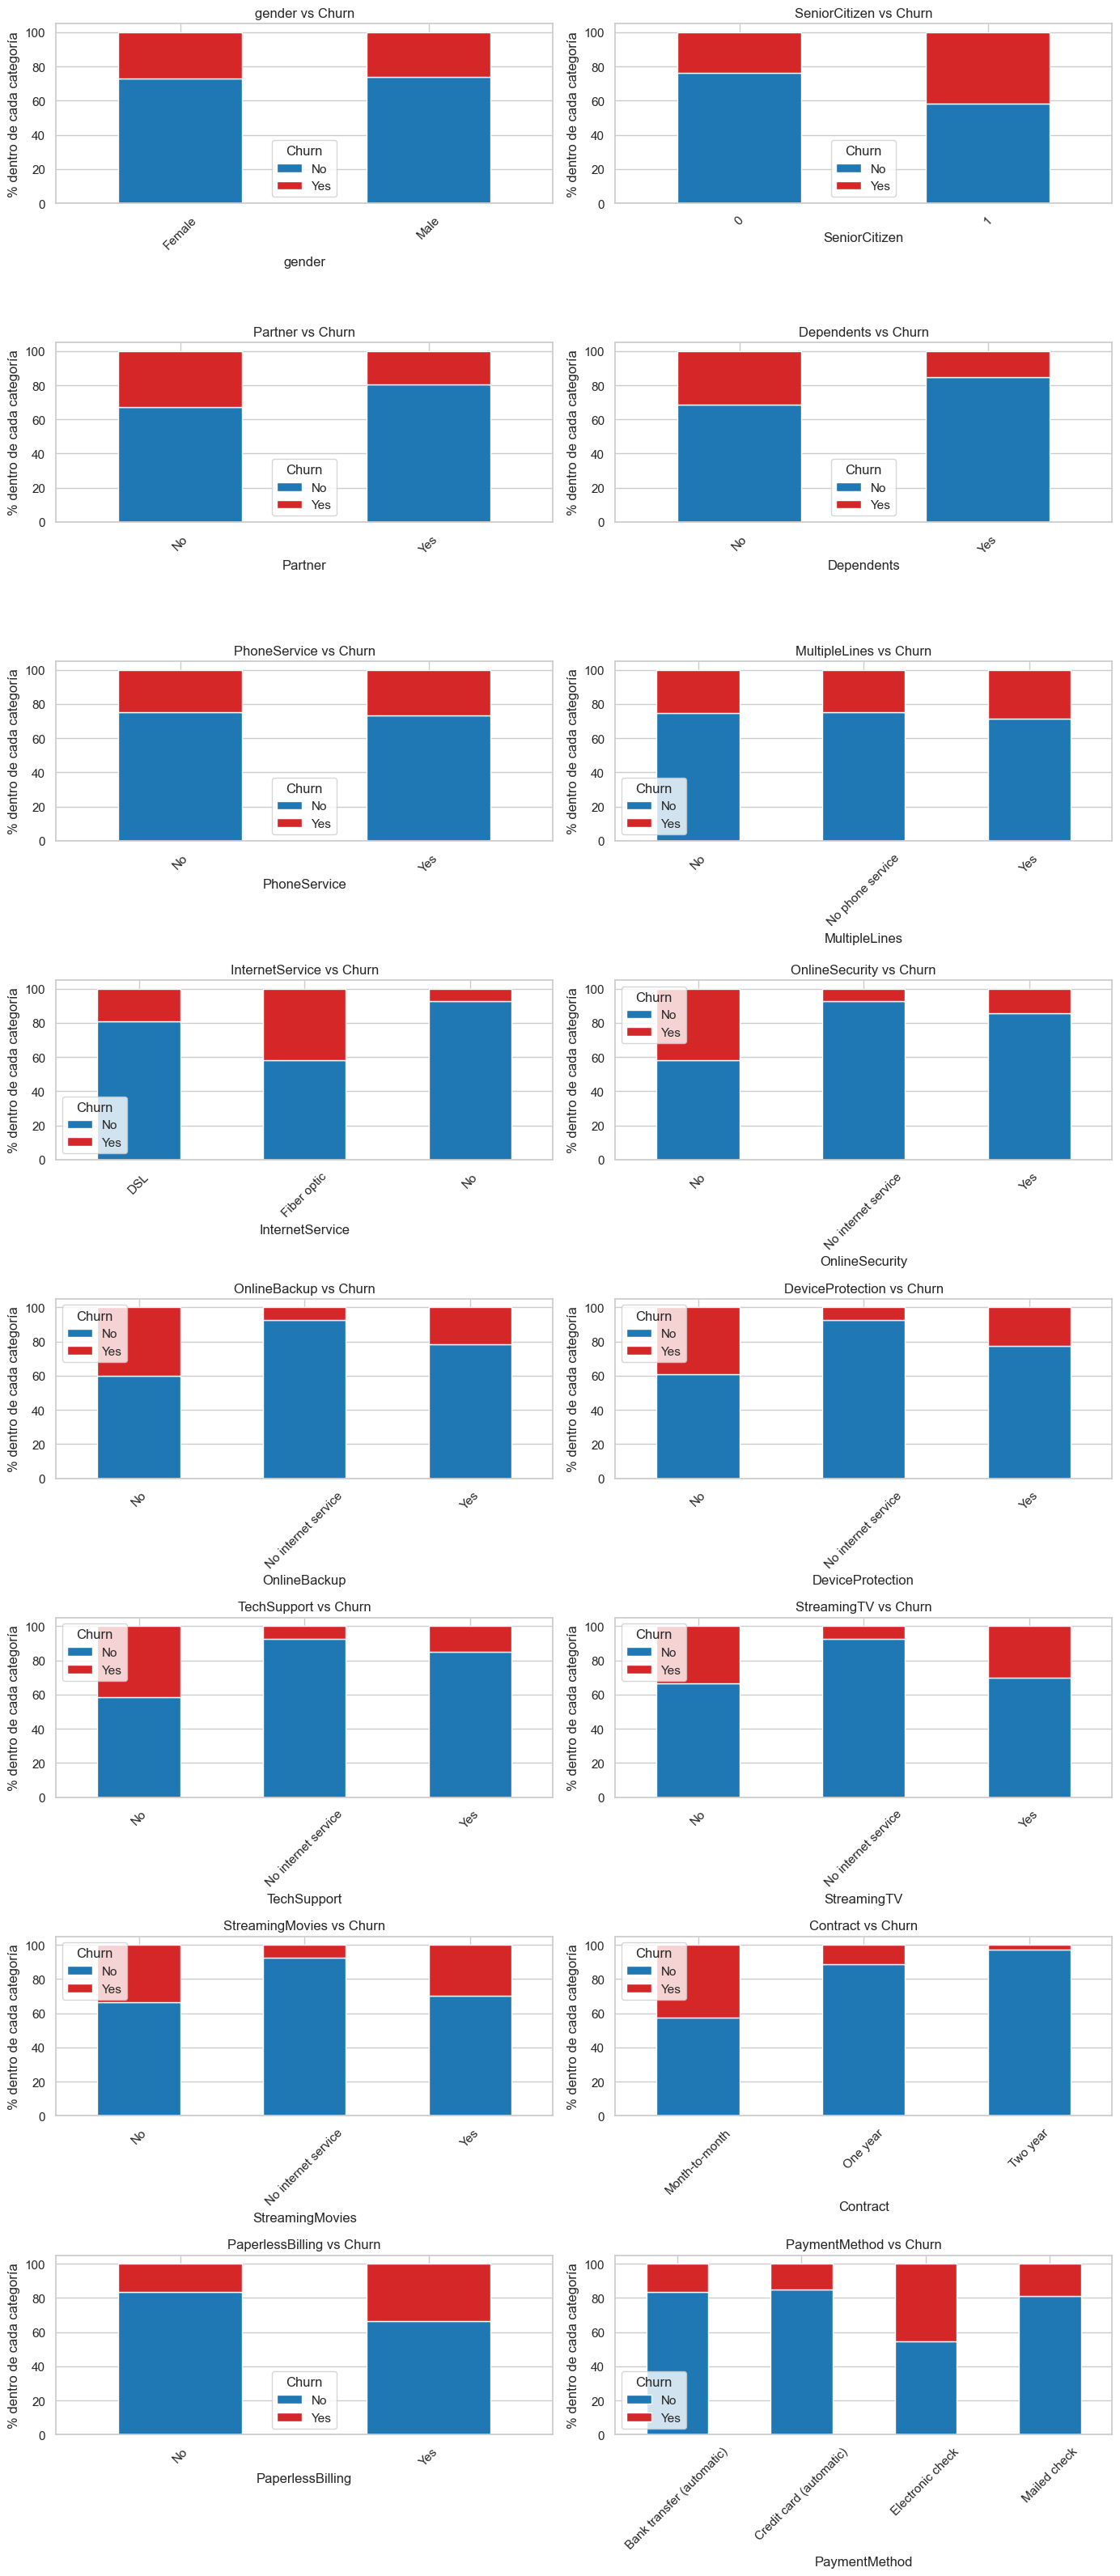

In [51]:
def plot_categorical_vs_target(data, columns, target="Churn", ncols=2):
    n = len(columns)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(columns):
        ax = axes[i]

        churn_rate = pd.crosstab(data[col], data[target], normalize="index") * 100
        churn_rate.plot(kind="bar", stacked=True, ax=ax, color=['#1f77b4', '#d62728'])

        ax.set_title(f"{col} vs {target}")
        ax.set_ylabel("% dentro de cada categoría")
        ax.set_xlabel(col)
        ax.tick_params(axis="x", rotation=45)
        ax.legend(title=target)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

plot_categorical_vs_target(df, CAT_COLS, target=TARGET, ncols=2)

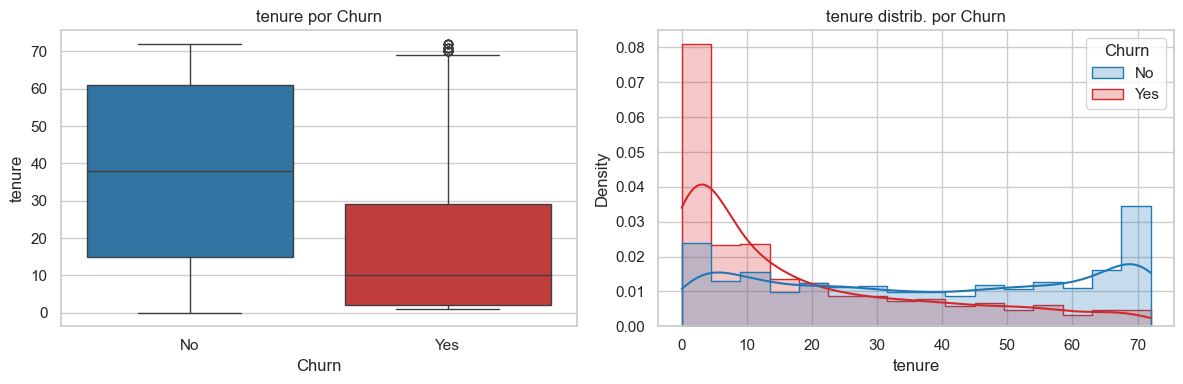


=== tenure por Churn ===
        count   mean    std  min   25%   50%   75%   max
Churn                                                   
No     5174.0  37.57  24.11  0.0  15.0  38.0  61.0  72.0
Yes    1869.0  17.98  19.53  1.0   2.0  10.0  29.0  72.0
------------------------------------------------------------


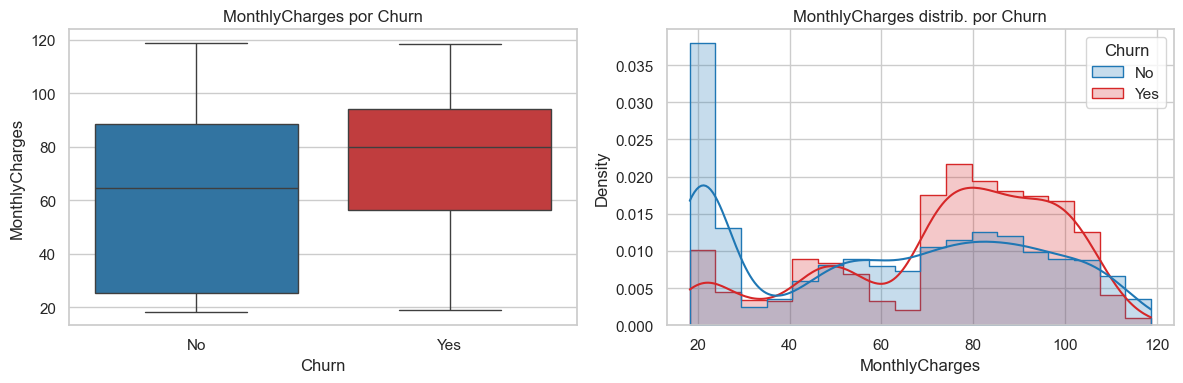


=== MonthlyCharges por Churn ===
        count   mean    std    min    25%    50%   75%     max
Churn                                                         
No     5174.0  61.27  31.09  18.25  25.10  64.43  88.4  118.75
Yes    1869.0  74.44  24.67  18.85  56.15  79.65  94.2  118.35
------------------------------------------------------------


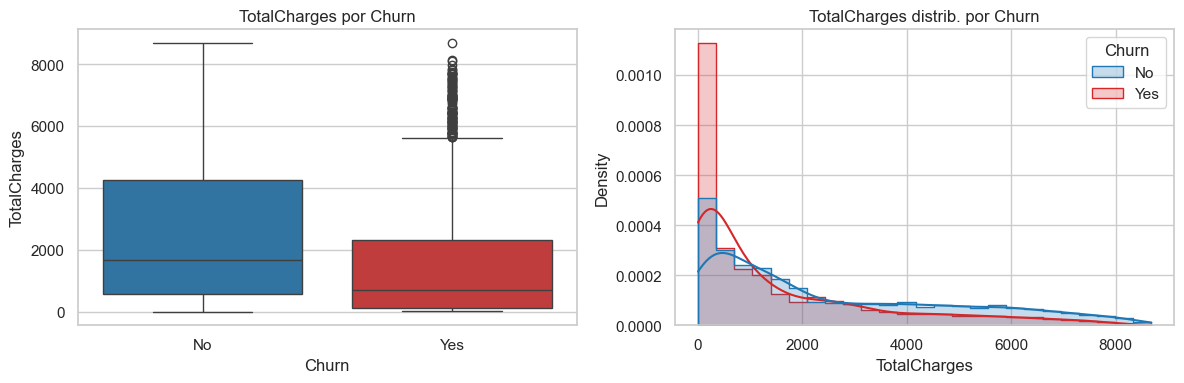


=== TotalCharges por Churn ===
        count     mean      std    min    25%      50%      75%      max
Churn                                                                   
No     5174.0  2549.91  2329.95   0.00  572.9  1679.52  4262.85  8672.45
Yes    1869.0  1531.80  1890.82  18.85  134.5   703.55  2331.30  8684.80
------------------------------------------------------------


In [52]:
def plot_numeric_vs_target(data, columns, target="Churn"):
    for col in columns:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # Boxplot en el primer eje
        sns.boxplot(
            data=data,
            x=target,
            y=col,
            ax=axes[0],
            palette=["#1f77b4", "#d62728"]
        )
        axes[0].set_title(f"{col} por {target}")

        # Histograma / densidad en el segundo eje
        sns.histplot(
            data=data,
            x=col,
            hue=target,
            kde=True,
            element="step",
            stat="density",
            common_norm=False,
            ax=axes[1],
            palette=["#1f77b4", "#d62728"]
        )
        axes[1].set_title(f"{col} distrib. por {target}")

        plt.tight_layout()
        plt.show()

        print(f"\n=== {col} por {target} ===")
        print(data.groupby(target)[col].describe().round(2))
        print("-" * 60)


plot_numeric_vs_target(df, NUM_COLS, target=TARGET)

## 🎯 Hallazgos clave del EDA

El análisis exploratorio muestra una señal clara para el problema de churn.

### Hallazgos principales

- Los clientes con menor `tenure` (antigüedad) presentan un riesgo significativamente mayor de abandono.
- El contrato `Month-to-month` aparece fuertemente asociado a mayor churn, mientras que los contratos de mayor duración actúan como un factor protector.
- Los clientes con `Fiber optic` y método de pago `Electronic check` muestran un perfil consistentemente más frágil frente al abandono.
- Los churners tienden a presentar `MonthlyCharges` más altos, pero `TotalCharges` más bajos, un patrón coherente con su menor antigüedad en la compañía.

### Conclusión

El dataset contiene patrones lógicos, consistentes y suficientemente informativos como para justificar una fase de modelado supervisado. En conjunto, el EDA sugiere que el churn no se distribuye aleatoriamente, sino que está relacionado con variables de antigüedad, estructura contractual, tipo de servicio y patrón de pago. El siguiente paso será construir baselines, comparar modelos y seleccionar una solución final equilibrando rendimiento, interpretabilidad e impacto de negocio.